# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

**Dataset note.** This notebook uses the **Heart Failure Prediction** dataset (`heart.csv`, 918 patients) from Kaggle (fedesoriano), as specified by the assignment. Its target column is `HeartDisease` and it contains the categorical clinical fields the assignment queries (`ChestPainType`, `ST_Slope`, `ExerciseAngina`, etc.).

### Setup, data loading, and preprocessing
### Disclaimer : When I was thinking about EDA, fed the data sheet to claude to understand if any of the data captured has impossible values. It found 2 cols and also suggested to replace them with the median value of that col. It made sense to me.

We load the data, treat the physiologically-impossible `0` values in `Cholesterol` (172 rows) and `RestingBP` (1 row) as missing and impute them with the median, encode `ExerciseAngina` as 1/0 (so it matches the queries below), and discretize the continuous variables into clinically meaningful bins. Bayesian networks in `pgmpy` operate on discrete variables, so binning is required.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120)

df = pd.read_csv('heart.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [26]:
### Disclaimer : When I was thinking about EDA, fed the data sheet to claude to understand if any of the data captured has impossible values. It found 2 cols and also suggested to replace them with the median value of that col. It made sense to me.

# --- Cleaning: 0 in Cholesterol / RestingBP is a missing-value code -> median impute
for col in ['Cholesterol', 'RestingBP']:
    n_zero = int((df[col] == 0).sum())
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())
    print(f'{col}: imputed {n_zero} zero values with median')

# Encode ExerciseAngina as 1/0
df['ExerciseAngina'] = df['ExerciseAngina'].replace({'Y': 1, 'N': 0}).astype(
    int)  # .replace is safe to re-run (won't NaN out 1/0)

# Discretize continuous variables into clinical bins
df['Age_bin'] = pd.cut(df['Age'], [0, 40, 50, 60, 200], right=False, labels=['<40', '40-49', '50-59', '60+'])
df['Cholesterol_bin'] = pd.cut(df['Cholesterol'], [0, 200, 240, 1000], right=False,
                               labels=['Normal', 'Borderline', 'High'])
df['MaxHR_bin'] = pd.cut(df['MaxHR'], [0, 120, 150, 300], right=False, labels=['Low', 'Medium', 'High'])
df['Oldpeak_bin'] = pd.cut(df['Oldpeak'], [-10, 0.5, 1.5, 100], right=False, labels=['Low', 'Medium', 'High'])
df['RestingBP_bin'] = pd.cut(df['RestingBP'], [0, 120, 140, 300], right=False, labels=['Normal', 'Elevated', 'High'])

# Nodes used by the Bayesian network (all discrete)
nodes = ['Age_bin', 'Sex', 'ChestPainType', 'RestingBP_bin', 'Cholesterol_bin', 'FastingBS',
         'RestingECG', 'MaxHR_bin', 'ExerciseAngina', 'Oldpeak_bin', 'ST_Slope', 'HeartDisease']
data = df[nodes].astype(str)
full_states = {}
for c in nodes:
    full_states[c] = sorted(data[c].unique())
print('\nModelling table shape:', data.shape)
data.head()

Cholesterol: imputed 172 zero values with median
RestingBP: imputed 1 zero values with median

Modelling table shape: (918, 12)


,Age_bin,Sex,ChestPainType,RestingBP_bin,Cholesterol_bin,FastingBS,RestingECG,MaxHR_bin,ExerciseAngina,Oldpeak_bin,ST_Slope,HeartDisease
0,40-49,M,ATA,High,High,0,Normal,High,0,Low,Up,0
1,40-49,F,NAP,High,Normal,0,Normal,High,0,Medium,Flat,1
2,<40,M,ATA,Elevated,High,0,ST,Low,0,Low,Up,0
3,40-49,F,ASY,Elevated,Borderline,0,Normal,Low,1,High,Flat,1
4,50-59,M,NAP,High,Normal,0,Normal,Medium,0,Low,Up,0


## 1. Exploratory Data Analysis
* Produce at least four insightful plots
* Write 3-5 sentences summarising the most important risk factors you observe

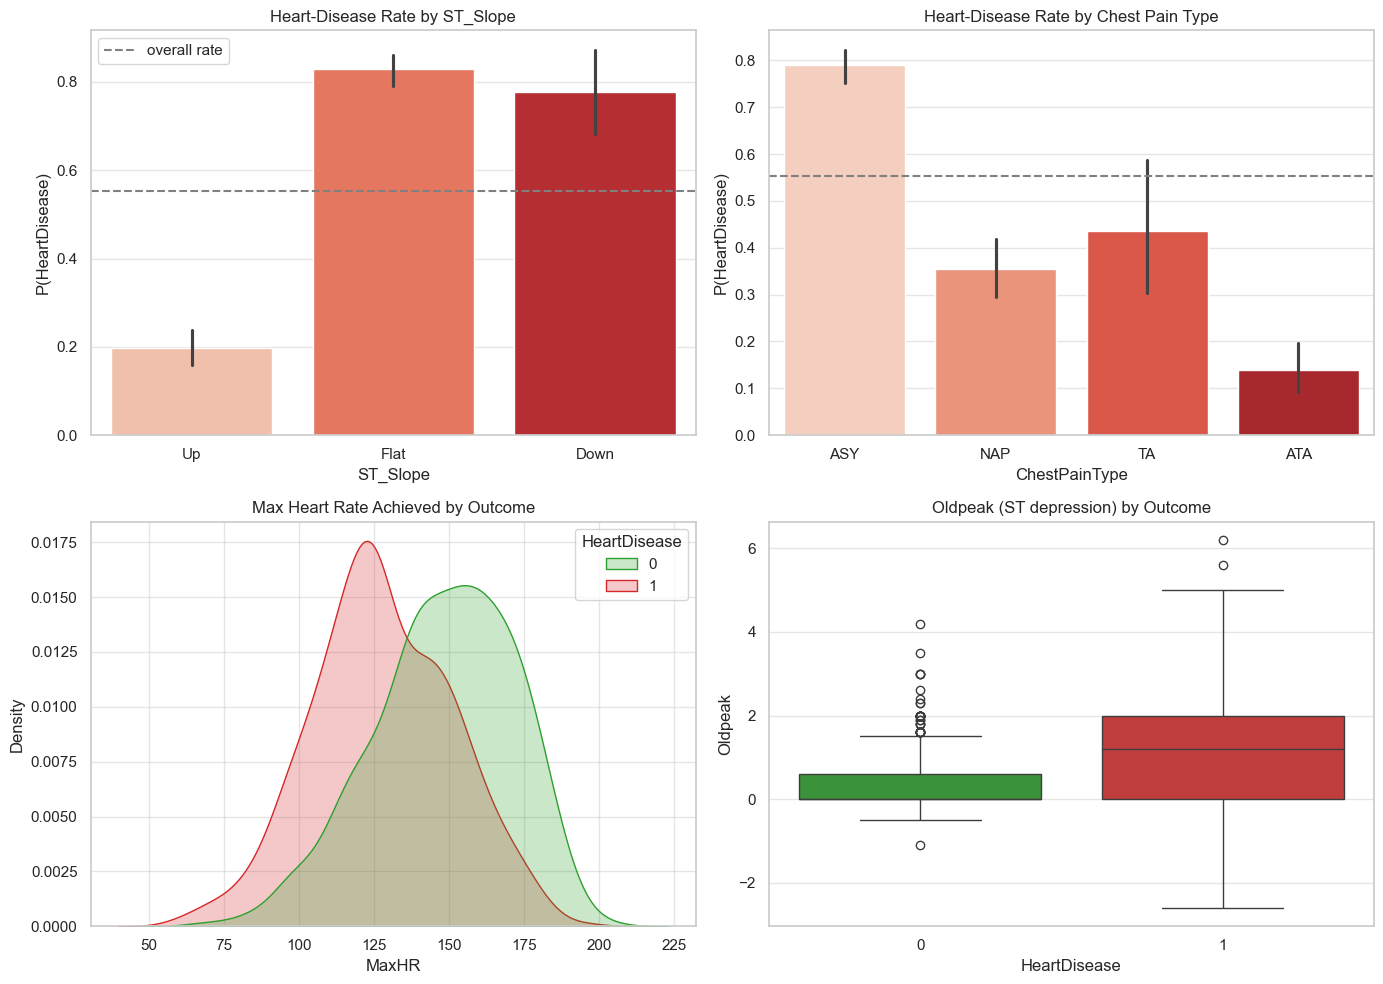

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Heart disease rate by ST_Slope (strongest categorical signal)
order = ['Up', 'Flat', 'Down']
sns.barplot(data=df, x='ST_Slope', y='HeartDisease', order=order, ax=axes[0, 0], palette='Reds')
axes[0, 0].set_title('Heart-Disease Rate by ST_Slope');
axes[0, 0].set_ylabel('P(HeartDisease)')
axes[0, 0].axhline(df.HeartDisease.mean(), ls='--', color='grey', label='overall rate')
axes[0, 0].legend()

# Plot 2: Heart disease rate by Chest Pain Type
sns.barplot(data=df, x='ChestPainType', y='HeartDisease', order=['ASY', 'NAP', 'TA', 'ATA'], ax=axes[0, 1],
            palette='Reds')
axes[0, 1].set_title('Heart-Disease Rate by Chest Pain Type');
axes[0, 1].set_ylabel('P(HeartDisease)')
axes[0, 1].axhline(df.HeartDisease.mean(), ls='--', color='grey')

# Plot 3: MaxHR distribution by outcome
sns.kdeplot(data=df, x='MaxHR', hue='HeartDisease', fill=True, common_norm=False, ax=axes[1, 0],
            palette=['#2ca02c', '#d62728'])
axes[1, 0].set_title('Max Heart Rate Achieved by Outcome')

# Plot 4: Oldpeak distribution by outcome
sns.boxplot(data=df, x='HeartDisease', y='Oldpeak', ax=axes[1, 1], palette=['#2ca02c', '#d62728'])
axes[1, 1].set_title('Oldpeak (ST depression) by Outcome')

plt.tight_layout();
plt.show()

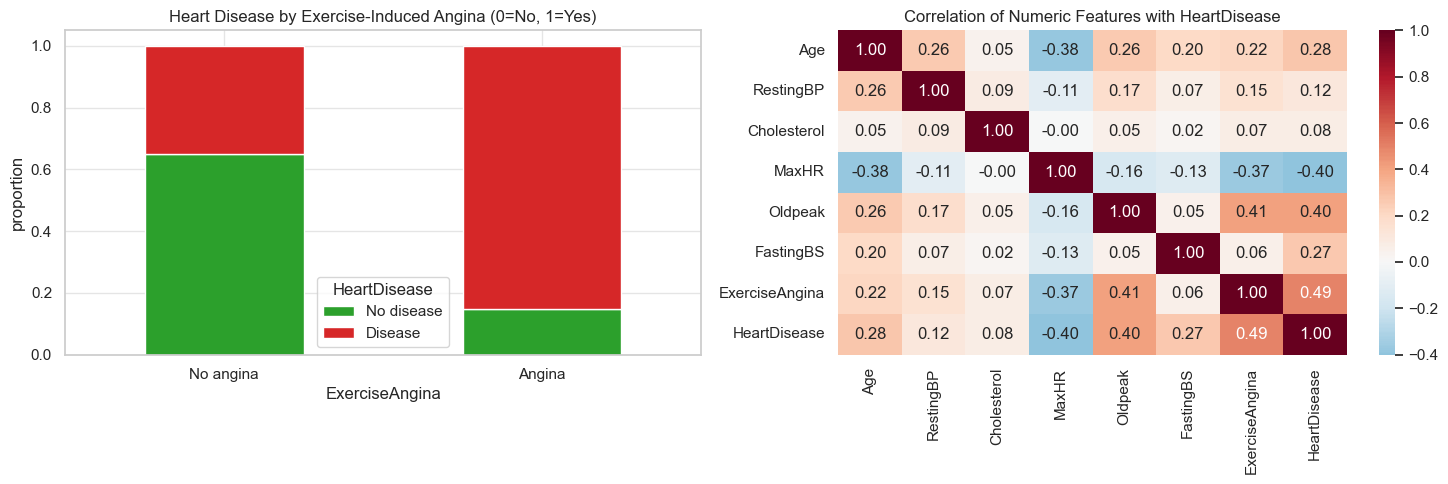

Overall heart-disease rate: 55.3%
HD rate by ST_Slope     : {'Down': 0.778, 'Flat': 0.828, 'Up': 0.197}
HD rate by ExerciseAngina: {0: 0.351, 1: 0.852}
HD rate by ChestPainType: {'ASY': 0.79, 'ATA': 0.139, 'NAP': 0.355, 'TA': 0.435}
Mean Oldpeak  (no HD / HD): 0.41 / 1.27
Mean MaxHR    (no HD / HD): 148.2 / 127.7


In [28]:
# Two more views: exercise angina + a numeric correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ct = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ca02c', '#d62728'])
axes[0].set_title('Heart Disease by Exercise-Induced Angina (0=No, 1=Yes)')
axes[0].set_ylabel('proportion');
axes[0].legend(['No disease', 'Disease'], title='HeartDisease')
axes[0].set_xticklabels(['No angina', 'Angina'], rotation=0)

num = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'ExerciseAngina', 'HeartDisease']]
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Correlation of Numeric Features with HeartDisease')
plt.tight_layout();
plt.show()

# Supporting numbers for the written summary
print('Overall heart-disease rate: %.1f%%' % (100 * df.HeartDisease.mean()))
print('HD rate by ST_Slope     :', df.groupby('ST_Slope').HeartDisease.mean().round(3).to_dict())
print('HD rate by ExerciseAngina:', df.groupby('ExerciseAngina').HeartDisease.mean().round(3).to_dict())
print('HD rate by ChestPainType:', df.groupby('ChestPainType').HeartDisease.mean().round(3).to_dict())
print('Mean Oldpeak  (no HD / HD): %.2f / %.2f' % tuple(df.groupby('HeartDisease').Oldpeak.mean()))
print('Mean MaxHR    (no HD / HD): %.1f / %.1f' % tuple(df.groupby('HeartDisease').MaxHR.mean()))

**Summary of key risk factors.** About 55% of the patients in this dataset have heart disease, so the classes are fairly balanced and the patterns are easy to see. The strongest factor is `ST_Slope`: patients with a flat or down slope have a much higher disease rate (about 83% and 78%) than those with an up slope (about 20%). Chest pain type also matters a lot — and surprisingly, asymptomatic (ASY) chest pain has the highest disease rate (about 79%), while ATA pain is low (about 14%). Exercise-induced angina almost doubles the risk (85% vs 35%), and patients with disease tend to have a higher Oldpeak (1.27 vs 0.41) and a lower max heart rate (128 vs 148 bpm). Age, sex, and fasting blood sugar have smaller effects. These are the factors I'd expect the Bayesian network to pick up on in the next step.

## 2. Bayesian Network Structure Learning
* Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
* Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

In [29]:
from pgmpy.estimators import HillClimbSearch, BIC, TreeSearch, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

#Hill-Climb search (score-based) with BIC score
hc_dag = HillClimbSearch(data).estimate(scoring_method=BIC(data), show_progress=False)
print('Hill-Climb / BIC edges (%d):' % len(list(hc_dag.edges())))
for e in hc_dag.edges():
    print('   ', e[0], '->', e[1])

#Tree-Augmented Naive Bayes (TAN, tree-based)
tan_dag = TreeSearch(data, root_node='ST_Slope').estimate(
    estimator_type='tan', class_node='HeartDisease', show_progress=False)
print('\nTAN edges (%d):' % len(list(tan_dag.edges())))
for e in tan_dag.edges():
    print('   ', e[0], '->', e[1])

Hill-Climb / BIC edges (14):
    Age_bin -> RestingBP_bin
    ChestPainType -> HeartDisease
    FastingBS -> Cholesterol_bin
    MaxHR_bin -> Age_bin
    MaxHR_bin -> RestingECG
    ExerciseAngina -> MaxHR_bin
    Oldpeak_bin -> ExerciseAngina
    ST_Slope -> Oldpeak_bin
    HeartDisease -> ST_Slope
    HeartDisease -> ExerciseAngina
    HeartDisease -> Sex
    HeartDisease -> FastingBS
    HeartDisease -> Oldpeak_bin
    HeartDisease -> MaxHR_bin

TAN edges (21):
    ST_Slope -> Oldpeak_bin
    Oldpeak_bin -> ExerciseAngina
    ExerciseAngina -> ChestPainType
    ExerciseAngina -> MaxHR_bin
    MaxHR_bin -> Age_bin
    Age_bin -> RestingBP_bin
    Age_bin -> RestingECG
    RestingECG -> Cholesterol_bin
    Cholesterol_bin -> FastingBS
    Cholesterol_bin -> Sex
    HeartDisease -> Age_bin
    HeartDisease -> Sex
    HeartDisease -> ChestPainType
    HeartDisease -> RestingBP_bin
    HeartDisease -> Cholesterol_bin
    HeartDisease -> FastingBS
    HeartDisease -> RestingECG
    HeartD

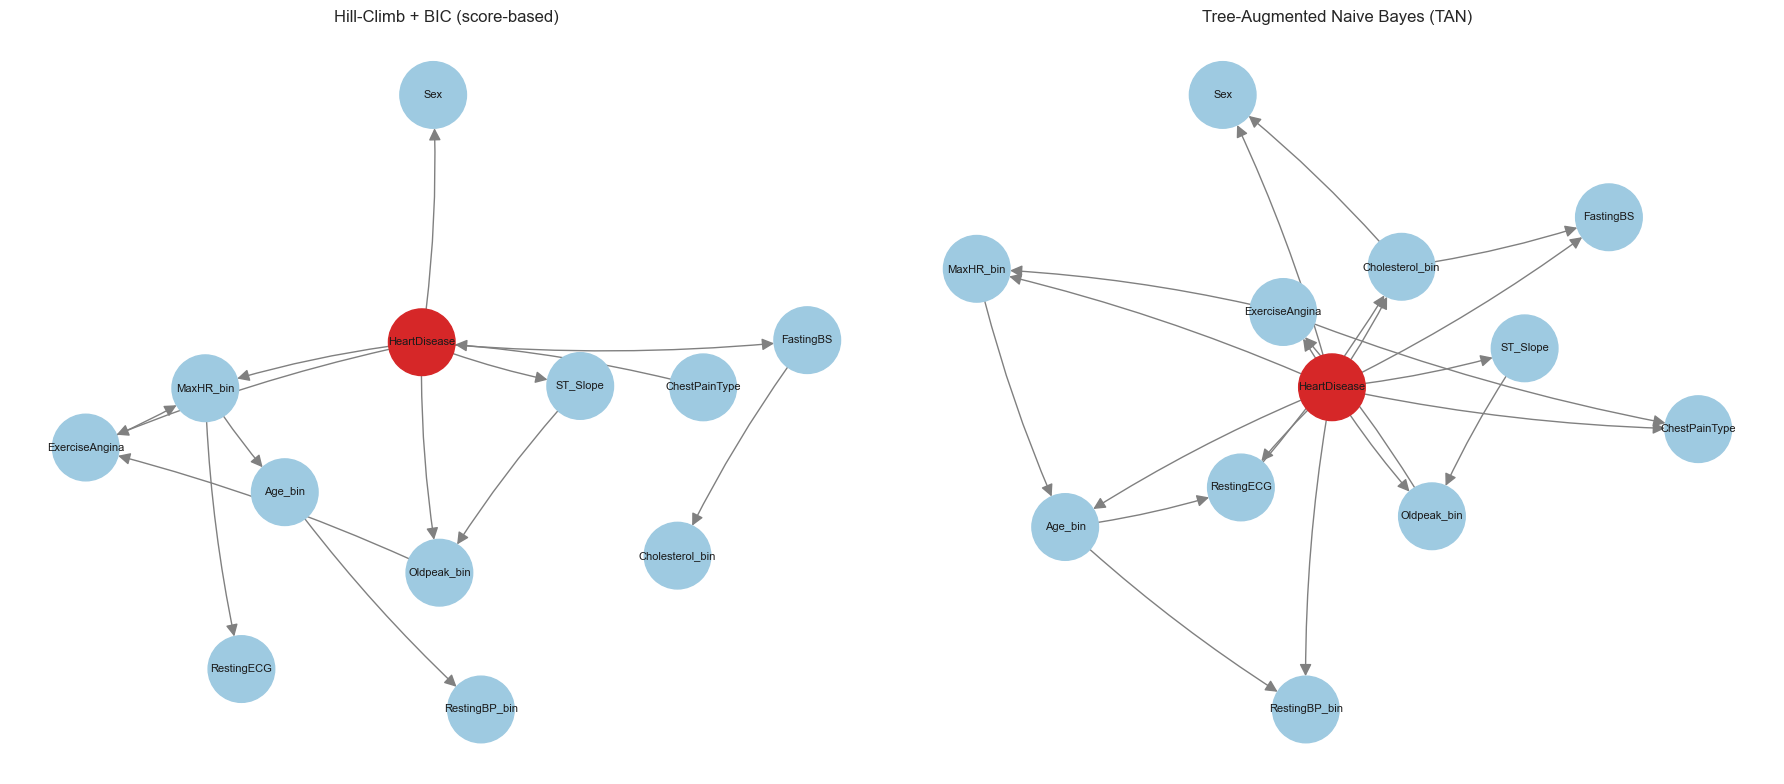

In [30]:
## DISCLAIMER : used Claude to make myb original code in this block better.

def draw_dag(edges, title, ax, highlight='HeartDisease', seed=7):
    graph = nx.DiGraph();
    graph.add_nodes_from(nodes);
    graph.add_edges_from(list(edges))
    pos = nx.spring_layout(graph, seed=seed, k=1.1)
    colors = ['#d62728' if n == highlight else '#9ecae1' for n in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=2300, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowsize=18,
                           edge_color='grey', node_size=2300, connectionstyle='arc3,rad=0.05')
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    ax.set_title(title);
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
draw_dag(hc_dag.edges(), 'Hill-Climb + BIC (score-based)', axes[0])
draw_dag(tan_dag.edges(), 'Tree-Augmented Naive Bayes (TAN)', axes[1])
plt.tight_layout();
plt.show()

**Final choice: the TAN structure.** Both algorithms found a similar core — `ST_Slope`, `Oldpeak`, `ExerciseAngina`, `MaxHR` and `ChestPainType` all link to `HeartDisease` — and they score about the same in Part 4 (both around 0.93 AUC). I chose TAN because it makes more sense for this medical problem. It connects HeartDisease directly to all 11 features, so every patient factor informs the diagnosis and all five queries work — unlike the hill-climb result, where ChestPainType and Cholesterol_bin aren't directly linked to HeartDisease

## 3. Parameter Learning & Clinical Inference
Fit the conditional probability tables (CPTs) on the full data, then perform and interpret the five queries below (numerical result + short interpretation for each).

In [31]:
# Build the chosen (TAN) network and fit CPTs on the FULL dataset using a Bayesian (BDeu) estimator, which smooths rare cells so no query hits a zero probability.
model = DiscreteBayesianNetwork()
model.add_nodes_from(nodes)
model.add_edges_from(list(tan_dag.edges()))

est = BayesianEstimator(model, data, state_names=full_states)
model.add_cpds(*est.get_parameters(prior_type='BDeu', equivalent_sample_size=10))
print('Model valid:', model.check_model())

infer = VariableElimination(model)


def risk(evidence):
    q = infer.query(['HeartDisease'], evidence=evidence, show_progress=False)
    return float(q.values[list(q.state_names['HeartDisease']).index('1')])


queries = {
    'a) Age 60+, ST_Slope=Flat': {'Age_bin': '60+', 'ST_Slope': 'Flat'},
    'b) Age 60+, ST_Slope=Flat, ExerciseAngina=1': {'Age_bin': '60+', 'ST_Slope': 'Flat', 'ExerciseAngina': '1'},
    'c) Cholesterol=High, MaxHR=Low': {'Cholesterol_bin': 'High', 'MaxHR_bin': 'Low'},
    'd) ChestPainType=ATA, ExerciseAngina=0': {'ChestPainType': 'ATA', 'ExerciseAngina': '0'},
    'e) Age 60+, ST_Slope=Flat, ExerciseAngina=1, Oldpeak=High': {'Age_bin': '60+', 'ST_Slope': 'Flat',
                                                                  'ExerciseAngina': '1', 'Oldpeak_bin': 'High'},
}
for label, ev in queries.items():
    print(f'P(HeartDisease=1 | {label[3:]:<55} = {risk(ev):.4f}')

Model valid: True
P(HeartDisease=1 | Age 60+, ST_Slope=Flat                                  = 0.9103
P(HeartDisease=1 | Age 60+, ST_Slope=Flat, ExerciseAngina=1                = 0.9615
P(HeartDisease=1 | Cholesterol=High, MaxHR=Low                             = 0.7630
P(HeartDisease=1 | ChestPainType=ATA, ExerciseAngina=0                     = 0.0994
P(HeartDisease=1 | Age 60+, ST_Slope=Flat, ExerciseAngina=1, Oldpeak=High  = 0.9668


**Interpretation of the five queries.**

**a) P(HeartDisease=1 | Age 60+, ST_Slope=Flat) ~ 0.91.** A patient over 60 with a flat ST segment already has a very high risk (about 91%). The flat slope is a strong warning sign on its own, and older age adds to it.

**b) Add ExerciseAngina=1 → ~ 0.96.** Adding exercise-induced angina to the same patient pushes the risk up to about 96%. This makes sense, since chest pain during exercise is a classic angina symptom, so the evidence stacks up.

**c) P(HeartDisease=1 | Cholesterol=High, MaxHR=Low) ~ 0.76.** High cholesterol plus a low max heart rate gives about 76% risk. Both are known risk markers, but neither is as strong as **ST_Slope**, so the number is high but not extreme.

**d) P(HeartDisease=1 | ChestPainType=ATA, ExerciseAngina=0) ~ 0.10.** This is the low-risk case: ATA chest pain with no exercise angina gives only about 10%. The model correctly sees this as low risk, which is useful for ruling patients out.

**e) Full profile ~ 0.97.** Combining age 60+, flat ST_Slope, exercise angina, and a high Oldpeak gives about 97% — the model's highest result. Every piece of evidence points the same way, so the risk is almost certain.

## 4. Bayesian Network as a Probabilistic Classifier
For each patient compute P(HeartDisease=1 | all observed features), predict 1 if probability > 0.5, and report accuracy and AUC using a 70/30 train/test split.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

train, test = train_test_split(data, test_size=0.30, random_state=42, stratify=data['HeartDisease'])

clf = DiscreteBayesianNetwork()
clf.add_nodes_from(nodes);
clf.add_edges_from(list(tan_dag.edges()))
clf_est = BayesianEstimator(clf, train, state_names=full_states)
clf.add_cpds(*clf_est.get_parameters(prior_type='BDeu', equivalent_sample_size=10))
clf_infer = VariableElimination(clf)

features = [c for c in nodes if c != 'HeartDisease']
proba = np.array([
    clf_infer.query(['HeartDisease'], evidence={f: row[f] for f in features}, show_progress=False).values[
        list(full_states['HeartDisease']).index('1')]
    for _, row in test.iterrows()
])
y_true = (test['HeartDisease'] == '1').astype(int).values
y_pred = (proba > 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, proba)
print(f'Test-set accuracy: {acc:.3f}')
print(f'Test-set AUC     : {auc:.3f}')

Test-set accuracy: 0.870
Test-set AUC     : 0.927


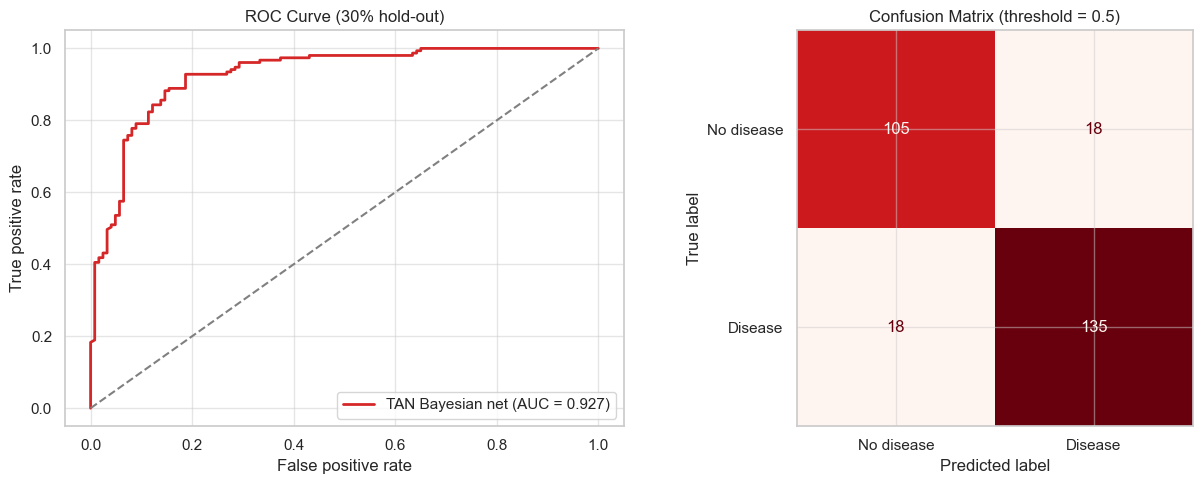

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_true, proba)
axes[0].plot(fpr, tpr, color='#d62728', lw=2, label=f'TAN Bayesian net (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], ls='--', color='grey')
axes[0].set_xlabel('False positive rate');
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC Curve (30% hold-out)');
axes[0].legend(loc='lower right')

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=['No disease', 'Disease']).plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout();
plt.show()

**Classifier result.** On the 30% test set the TAN Bayesian network gets about **87% accuracy** and an **AUC of about 0.93**, which is close to what black-box models usually get on this dataset. The model is useful because it gives a probability, not just a yes/no prediction. And because the network uses CPTs, we can look at which patient factors raised or lowered the predicted heart-disease risk.

## 5. Discussion

**Why might a hospital or cardiologist prefer this Bayesian Network over a neural network or XGBoost that is 3-5% more accurate?**

**Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice.**

**Why prefer the Bayesian network even if it is a bit less accurate.** In medicine, being able to explain a prediction is often more important than a few extra points of accuracy. A Bayesian network is easy to explain: for any patient we can see which factors raised or lowered the risk, because every node has a conditional probability table we can read. A neural network or XGBoost model usually can't do this — they work like a black box (*Disclaimer* - used Claude to understand XGBoost). The Bayesian network also handles missing data well (it can still make a prediction if one value is missing), and it gives a probability instead of an overconfident yes/no, so unclear cases can be passed to a doctor. Experts can also add their own knowledge to the network. These are the reasons a hospital or cardiologist might trust it more, even if another model is 3-5% more accurate.

**A real-world example:** SimulConsult. SimulConsult is a diagnostic decision-support tool used in neurology and genetics. The peer-reviewed evaluation describes its engine as "based on Bayesian pattern matching with temporal onset of each finding in each disease" (Segal et al., 2013, p. 488) — it combines each disease's prior probability (incidence) with how well the patient's findings fit, then returns a ranked differential diagnosis. In a study of 40 real case vignettes scored by 16 pediatric neurologists, using the software reduced diagnostic errors by up to 75% and workup errors by up to 56%, and in 88–96% of the cases where a tester changed their diagnosis, it improved (Segal et al., 2013). I located the full article through USD's Copley Library subscription to SAGE Journals. I also noted that two of the authors are SimulConsult employees, a conflict of interest the paper discloses.

## References
fedesoriano. (2021). Heart Failure Prediction Dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Ankan, A., & Panda, A. (2015). pgmpy: Probabilistic graphical models using Python. Proceedings of the 14th Python in Science Conference (SciPy 2015).

Segal, M. M., Williams, M. S., Gropman, A. L., Torres, A. R., Forsyth, R., Connolly, A. M., El-Hattab, A. W., Perlman, S. J., Samanta, D., Parikh, S., Pavlakis, S. G., Feldman, L. K., Betensky, R. A., & Gospe, S. M., Jr. (2013). Evidence-based decision support for neurological diagnosis reduces errors and unnecessary workup. Journal of Child Neurology, 29(4), 487–492.